In [18]:
import numpy as np
import matplotlib.pyplot as plt

In [19]:
nu_inf = 1.5e-6      # Kinematic viscosity (m^2/s)
U_inf = 30         # Freestream velocity (m/s)
L = 1              # Characteristic length (m)
delta = 0.005        # Initial boundary layer thickness (m)

# Estimate initial x0 assuming standard laminar growth: delta approx 5.0 * sqrt(nu*x / U_inf)
x0 = (delta / 5.0)**2 * (U_inf / nu_inf) 
x_max = x0 + 40 * L  # Marching up to 40 L downstream
dx = 0.01            # Marching step size in x

In [24]:

ny = 150  # Number of grid points in y
y_max = 1 # Maximum y domain height
s = 10  # Grid stretching factor

# Uniform computational grid (eta)
eta = np.linspace(0, 1.0, ny)
d_eta = eta[1]-eta[0]

# Physical stretched grid (y)
y = y_max * (np.sinh(s * eta) / np.sinh(s))

# Metric transformations (chain rule terms d_eta/dy and d2_eta/dy2)
h1 = np.sinh(s) / (s * y_max * np.cosh(s * eta))
h2 = - (np.sinh(s) * np.sinh(s * eta)) / (y_max * np.cosh(s * eta)**3)

In [25]:
u = np.zeros(ny)
v = np.zeros(ny)

# Piecewise initial condition for u
for i in range(ny):
    y_norm = y[i] / delta
    if y_norm <= 1.0:
        u[i] = U_inf * (y_norm * (1.5 - 0.5 * (y_norm**2)))
    else:
        u[i] = U_inf

In [22]:
#central diff for eta
D1 = np.zeros((ny, ny))
D2 = np.zeros((ny, ny))

for i in range(1, ny - 1):
    if i == 1 or i == ny - 2:
        #2nd order cd
        D1[i, i-1]= -1/(2*d_eta)
        D1[i, i+1]= 1/(2*d_eta)
        
        D2[i, i-1]= 1/d_eta**2
        D2[i, i]= -2/d_eta**2
        D2[i, i+1]= 1/d_eta**2
    else:
        #4th order cd
        D1[i, i-2]= 1/(12*d_eta)
        D1[i, i-1]= -8/(12*d_eta)
        D1[i, i+1]= 8/(12*d_eta)
        D1[i, i+2]= -1/(12*d_eta)
        
        D2[i, i-2]= -1/(12*d_eta**2)
        D2[i, i-1]= 16/(12*d_eta**2)
        D2[i, i]= -30/(12*d_eta**2)
        D2[i, i+1]= 16/(12*d_eta**2)
        D2[i, i+2]= -1/(12*d_eta**2)

In [26]:
#C-N in x-dir
x = x0
x_storage_points = [x0 + 10*L, x0 + 20*L, x0 + 30*L, x0 + 40*L]
stored_profiles = {'y': y, x0: u.copy()}

while x < x_max:
    # 1. Calculate spatial differential operator matrix L_op
    L_matrix = np.zeros((ny, ny))
    for i in range(1, ny - 1):
        alpha = nu_inf * h1[i]**2
        beta = nu_inf * h1[i] * h2[i] - v[i] * h1[i]
        L_matrix[i, :] = (alpha * D2[i, :] + beta * D1[i, :]) / u[i]
        
    #init
    I = np.eye(ny)
    A = I - 0.5*dx*L_matrix
    b = I + 0.5*dx*L_matrix

    #top boundary
    A[-1, :] = 0; 
    A[-1, -1] = 1; 
    b[-1, :] = 0; 
    b[-1, -1] = U_inf 
    #bottom boundary
    A[0, :] = 0; 
    A[0, 0] = 1; 
    b[0, :] = 0; 
    b[0, 0] = 0        
    
    #rhs
    rhs = B@u
    rhs[0]=0
    rhs[-1]=U_inf
    
    # Using standard numpy solver since matrix is small (150x150)
    u_new = np.linalg.solve(A, rhs)
    
    # 4. Solve Continuity for v^{n+1} using trapezoidal integration
    du_dx = (u_new - u) / dx
    v_new = np.zeros(ny)
    for i in range(1, ny):
        v_new[i] = v_new[i-1] - 0.5 * (y[i] - y[i-1]) * (du_dx[i] + du_dx[i-1])
        
    # 5. Update for next step
    u = u_new.copy()
    v = v_new.copy()
    x += dx
    
    # Store profiles at specific locations
    for target_x in x_storage_points.copy():
        if x >= target_x:
            stored_profiles[target_x] = u.copy()
            x_storage_points.remove(target_x)

C:\Users\gomes\AppData\Local\Temp\ipykernel_9136\46186846.py:31: RuntimeWarning: overflow encountered in matmul
  rhs = B@u
C:\Users\gomes\AppData\Local\Temp\ipykernel_9136\46186846.py:31: RuntimeWarning: invalid value encountered in matmul
  rhs = B@u


At x = 20.00 m:
  Displacement Thickness: 0.00188 m
  Momentum Thickness:     0.00070 m
  Shape Factor:           2.692

At x = 30.00 m:
  Displacement Thickness: 0.00226 m
  Momentum Thickness:     0.00082 m
  Shape Factor:           2.738

At x = 40.00 m:
  Displacement Thickness: 0.00253 m
  Momentum Thickness:     0.00095 m
  Shape Factor:           2.672

At x = 50.00 m:
  Displacement Thickness: 0.00278 m
  Momentum Thickness:     0.00106 m
  Shape Factor:           2.634

At x = 60.00 m:
  Displacement Thickness: 0.00302 m
  Momentum Thickness:     0.00115 m
  Shape Factor:           2.613



<>:25: SyntaxWarning: invalid escape sequence '\i'
<>:25: SyntaxWarning: invalid escape sequence '\i'
C:\Users\gomes\AppData\Local\Temp\ipykernel_9136\143031515.py:25: SyntaxWarning: invalid escape sequence '\i'
  plt.xlabel('$u / U_{\infty}$')


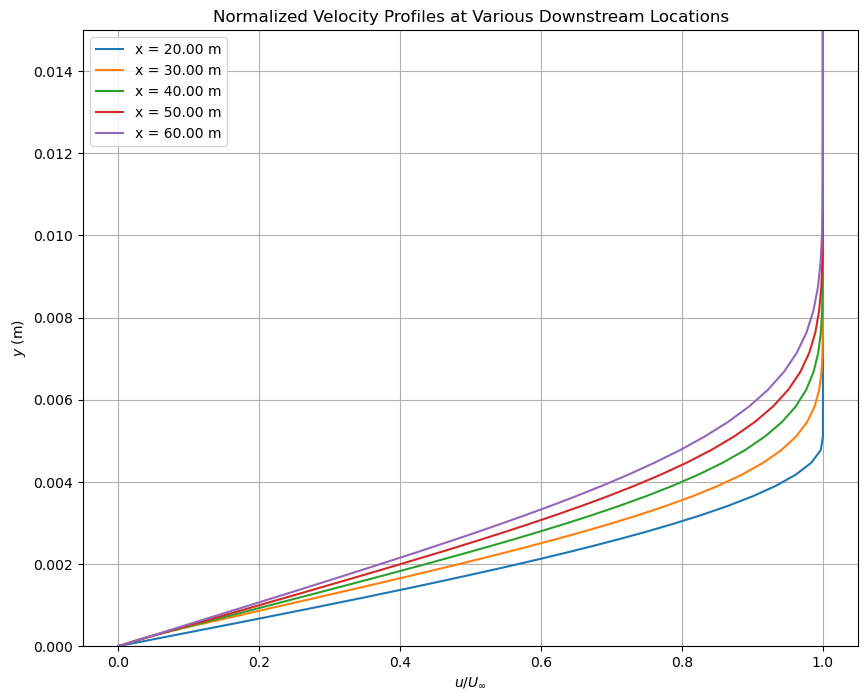

In [17]:
#plot
plt.figure(figsize=(10, 8))

for x_loc, u_prof in stored_profiles.items():
    if x_loc != 'y':
        # --- Thickness Calculations using np.trapz ---
        integrand_disp = 1.0 - (u_prof / U_inf)
        disp_thick = np.trapezoid(integrand_disp, x=y)
        
        integrand_mom = (u_prof / U_inf) * (1.0 - (u_prof / U_inf))
        mom_thick = np.trapezoid(integrand_mom, x=y)
        
        # Shape factor
        shape_factor = disp_thick / mom_thick
        
        print(f"At x = {x_loc:.2f} m:")
        print(f"  Displacement Thickness: {disp_thick:.5f} m")
        print(f"  Momentum Thickness:     {mom_thick:.5f} m")
        print(f"  Shape Factor:           {shape_factor:.3f}\n")
        
        # --- Plotting ---
        plt.plot(u_prof / U_inf, y, label=f'x = {x_loc:.2f} m')

plt.title('Normalized Velocity Profiles at Various Downstream Locations')
plt.xlabel('$u / U_{\infty}$')
plt.ylabel('$y$ (m)')
plt.ylim(0, 0.015) 
plt.legend()
plt.grid(True)
plt.show()

## Finding eta coordinate derivs:

In [51]:
import sympy as sp
# symbols
eta, s, y_max = sp.symbols('eta s y_max')

# mapping
y = y_max * sp.sinh(s*eta) / sp.sinh(s)
dy_deta = sp.diff(y, eta)
h1=sp.simplify(dy_deta)
deta_dy = sp.simplify(1 / dy_deta)
h2 = sp.simplify(deta_dy * sp.diff(deta_dy, eta))
sp.latex(h2)
sp.latex(h1)
print("...")
latex_expr = sp.latex(h1)
print(f"$$\n{latex_expr}\n$$")

...
$$
\frac{s y_{max} \cosh{\left(\eta s \right)}}{\sinh{\left(s \right)}}
$$


$$
\frac{\partial\eta}{\partial y} = \frac{s y_{max} \cosh{\left(\eta s \right)}}{\sinh{\left(s \right)}}
$$

In [52]:
latex_expr2 = sp.latex(h2)
print(f"$$\n{latex_expr2}\n$$")

$$
- \frac{\sinh^{2}{\left(s \right)} \sinh{\left(\eta s \right)}}{s y_{max}^{2} \cosh^{3}{\left(\eta s \right)}}
$$


$$
\frac{\partial^2\eta}{\partial y^2}=- \frac{\sinh^{2}{\left(s \right)} \sinh{\left(\eta s \right)}}{s y_{max}^{2} \cosh^{3}{\left(\eta s \right)}}
$$